### Based on `notebooks/03_probe_validation_analysis.ipynb`

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load results
with open('../results/probe_validation/Qwen__Qwen3-4B_probe_validation_results.json') as f:
    qwen_results = json.load(f)

with open('../results/probe_validation/microsoft__Phi-3-mini-4k-instruct_probe_validation_results.json') as f:
    phi_results = json.load(f)
    
with open('../results/probe_validation/meta-llama__Llama-3.2-3B_probe_validation_results.json') as f:
    llama_results = json.load(f)

for results in [qwen_results, phi_results, llama_results]:
    print(f"Model: {results['metadata']['model']}")
    print("Experiment:", results['metadata']['experiment'])
    print("Timestamp:", results['metadata']['timestamp'])
    print("Git commit:", results['metadata']['git_commit'])

Model: {'name': 'Qwen/Qwen3-4B', 'tag': 'Qwen__Qwen3-4B', 'source': 'huggingface'}
Experiment: probe_semantic_validation
Timestamp: 2026-04-02T21:14:41.177635+00:00
Git commit: 553e005fbfe4b3a62bce36e8091d2f8fc56f066e
Model: {'name': 'microsoft/Phi-3-mini-4k-instruct', 'tag': 'microsoft__Phi-3-mini-4k-instruct', 'source': 'huggingface'}
Experiment: probe_semantic_validation
Timestamp: 2026-04-02T21:14:48.525678+00:00
Git commit: 553e005fbfe4b3a62bce36e8091d2f8fc56f066e
Model: {'name': 'meta-llama/Llama-3.2-3B', 'tag': 'meta-llama__Llama-3.2-3B', 'source': 'huggingface'}
Experiment: probe_semantic_validation
Timestamp: 2026-04-02T21:14:56.469437+00:00
Git commit: 553e005fbfe4b3a62bce36e8091d2f8fc56f066e


# Result Overview

In [2]:
# Create DataFrame from results
dfs = {}
for results in [qwen_results, phi_results, llama_results]:
    explicit_df = pd.DataFrame(results['explicit_results'])
    implicit_df = pd.DataFrame(results['implicit_results'])

    # Merge
    df = explicit_df.merge(implicit_df, on='layer')
    df['gap'] = df['test_acc'] - df['implicit_acc']
    df['status'] = df['implicit_acc'].apply(
        lambda x: 'SEMANTIC' if x >= 0.70 else ('WEAK' if x >= 0.55 else 'LEXICAL')
    )

    model_name = results['metadata']['model']["name"].split('/')[-1]
    dfs[model_name] = df

for model_name, df in dfs.items():
    print(f"\nModel: {model_name}")
    print(df)



Model: Qwen3-4B
    layer  cv_mean    cv_std  test_acc  implicit_acc   gap    status
0       0   0.6500  0.122474      0.70          0.70  0.00  SEMANTIC
1       1   0.6750  0.127475      0.75          0.72  0.03  SEMANTIC
2       2   0.6750  0.155121      0.65          0.72 -0.07  SEMANTIC
3       3   0.7000  0.164886      0.80          0.72  0.08  SEMANTIC
4       4   0.7000  0.160078      0.85          0.72  0.13  SEMANTIC
5       5   0.7250  0.128695      0.85          0.73  0.12  SEMANTIC
6       6   0.7250  0.128695      0.80          0.78  0.02  SEMANTIC
7       7   0.7750  0.122474      0.85          0.78  0.07  SEMANTIC
8       8   0.8250  0.046771      0.80          0.86 -0.06  SEMANTIC
9       9   0.8125  0.079057      0.90          0.84  0.06  SEMANTIC
10     10   0.8250  0.072887      0.90          0.82  0.08  SEMANTIC
11     11   0.8125  0.068465      0.90          0.84  0.06  SEMANTIC
12     12   0.8375  0.063738      0.90          0.84  0.06  SEMANTIC
13     13   0.812

## Visualization: Explicit vs Implicit Accuracy by Layer

### Analysing Qwen

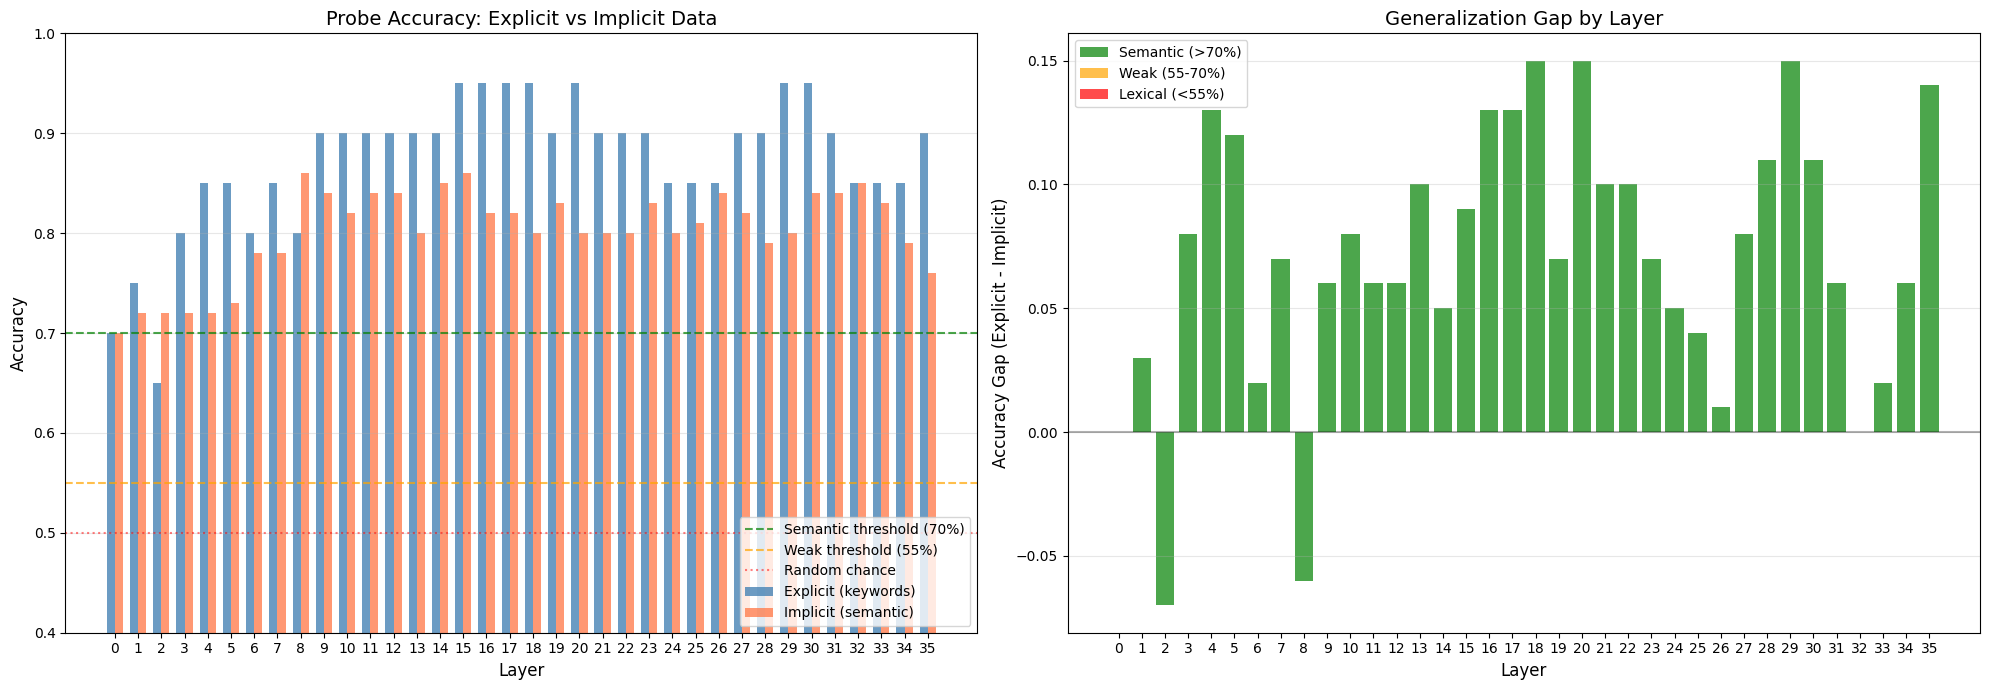


Figure saved to results/figures/probe_validation_Qwen3-4B.png


In [3]:
# Plotting for Qwen - 
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
model_name = "Qwen3-4B"
df = dfs[model_name]
# Plot 1: Accuracy comparison
ax1 = axes[0]
x = df['layer']
width = 0.35

bars1 = ax1.bar(x - width/2, df['test_acc'], width, label='Explicit (keywords)', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, df['implicit_acc'], width, label='Implicit (semantic)', color='coral', alpha=0.8)

ax1.axhline(y=0.70, color='green', linestyle='--', alpha=0.7, label='Semantic threshold (70%)')
ax1.axhline(y=0.55, color='orange', linestyle='--', alpha=0.7, label='Weak threshold (55%)')
ax1.axhline(y=0.50, color='red', linestyle=':', alpha=0.5, label='Random chance')

ax1.set_xlabel('Layer', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Probe Accuracy: Explicit vs Implicit Data', fontsize=14)
ax1.set_xticks(x)
ax1.set_ylim(0.4, 1.0)
ax1.legend(loc='lower right')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Gap between explicit and implicit
ax2 = axes[1]
colors = ['green' if s == 'SEMANTIC' else ('orange' if s == 'WEAK' else 'red') for s in df['status']]
ax2.bar(x, df['gap'], color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

ax2.set_xlabel('Layer', fontsize=12)
ax2.set_ylabel('Accuracy Gap (Explicit - Implicit)', fontsize=12)
ax2.set_title('Generalization Gap by Layer', fontsize=14)
ax2.set_xticks(x)
ax2.grid(axis='y', alpha=0.3)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Semantic (>70%)'),
    Patch(facecolor='orange', alpha=0.7, label='Weak (55-70%)'),
    Patch(facecolor='red', alpha=0.7, label='Lexical (<55%)')
]
ax2.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig(f'../results/figures/probe_validation_{model_name}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to results/figures/probe_validation_{model_name}.png")

In [4]:
print("=" * 70)
print("LAYER-BY-LAYER ANALYSIS")
print("=" * 70)
print()

for _, row in df.iterrows():
    layer = int(row['layer'])
    explicit = row['test_acc']
    implicit = row['implicit_acc']
    gap = row['gap']
    status = row['status']
    
    icon = '✓' if status == 'SEMANTIC' else ('○' if status == 'WEAK' else '✗')
    
    print(f"Layer {layer:2d}: {icon} {status:8s} | Explicit: {explicit:.1%} | Implicit: {implicit:.1%} | Gap: {gap:+.1%}")

LAYER-BY-LAYER ANALYSIS

Layer  0: ✓ SEMANTIC | Explicit: 70.0% | Implicit: 70.0% | Gap: +0.0%
Layer  1: ✓ SEMANTIC | Explicit: 75.0% | Implicit: 72.0% | Gap: +3.0%
Layer  2: ✓ SEMANTIC | Explicit: 65.0% | Implicit: 72.0% | Gap: -7.0%
Layer  3: ✓ SEMANTIC | Explicit: 80.0% | Implicit: 72.0% | Gap: +8.0%
Layer  4: ✓ SEMANTIC | Explicit: 85.0% | Implicit: 72.0% | Gap: +13.0%
Layer  5: ✓ SEMANTIC | Explicit: 85.0% | Implicit: 73.0% | Gap: +12.0%
Layer  6: ✓ SEMANTIC | Explicit: 80.0% | Implicit: 78.0% | Gap: +2.0%
Layer  7: ✓ SEMANTIC | Explicit: 85.0% | Implicit: 78.0% | Gap: +7.0%
Layer  8: ✓ SEMANTIC | Explicit: 80.0% | Implicit: 86.0% | Gap: -6.0%
Layer  9: ✓ SEMANTIC | Explicit: 90.0% | Implicit: 84.0% | Gap: +6.0%
Layer 10: ✓ SEMANTIC | Explicit: 90.0% | Implicit: 82.0% | Gap: +8.0%
Layer 11: ✓ SEMANTIC | Explicit: 90.0% | Implicit: 84.0% | Gap: +6.0%
Layer 12: ✓ SEMANTIC | Explicit: 90.0% | Implicit: 84.0% | Gap: +6.0%
Layer 13: ✓ SEMANTIC | Explicit: 90.0% | Implicit: 80.0% | Gap:

In [5]:
summary = qwen_results['summary']

print("=" * 50)
print("VALIDATION SUMMARY")
print("=" * 50)
print(f"Best semantic layer: {summary['best_semantic_layer']}")
print(f"Best implicit accuracy: {summary['best_implicit_accuracy']:.1%}")
print(f"Validation passed: {summary['validation_passed']}")
print()

# Statistics
semantic_layers = df[df['status'] == 'SEMANTIC']['layer'].tolist()
weak_layers = df[df['status'] == 'WEAK']['layer'].tolist()
lexical_layers = df[df['status'] == 'LEXICAL']['layer'].tolist()

print(f"Semantic layers (>70%): {semantic_layers}")
print(f"Weak layers (55-70%): {weak_layers}")
print(f"Lexical layers (<55%): {lexical_layers}")
print()

print(f"Mean explicit accuracy: {df['test_acc'].mean():.1%}")
print(f"Mean implicit accuracy: {df['implicit_acc'].mean():.1%}")
print(f"Mean generalization gap: {df['gap'].mean():.1%}")

VALIDATION SUMMARY
Best semantic layer: 8
Best implicit accuracy: 86.0%
Validation passed: True

Semantic layers (>70%): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
Weak layers (55-70%): []
Lexical layers (<55%): []

Mean explicit accuracy: 87.2%
Mean implicit accuracy: 80.1%
Mean generalization gap: 7.1%


### Observations

1. All layers encode semantic temporal features
2. At layer no. 8 the explicit accuracy jumps by 12%
3. Layer 2 and 8 has a gap of generalization gap of 10% **(Implicit > Explicit)** <- This might be interesting?


## SPD

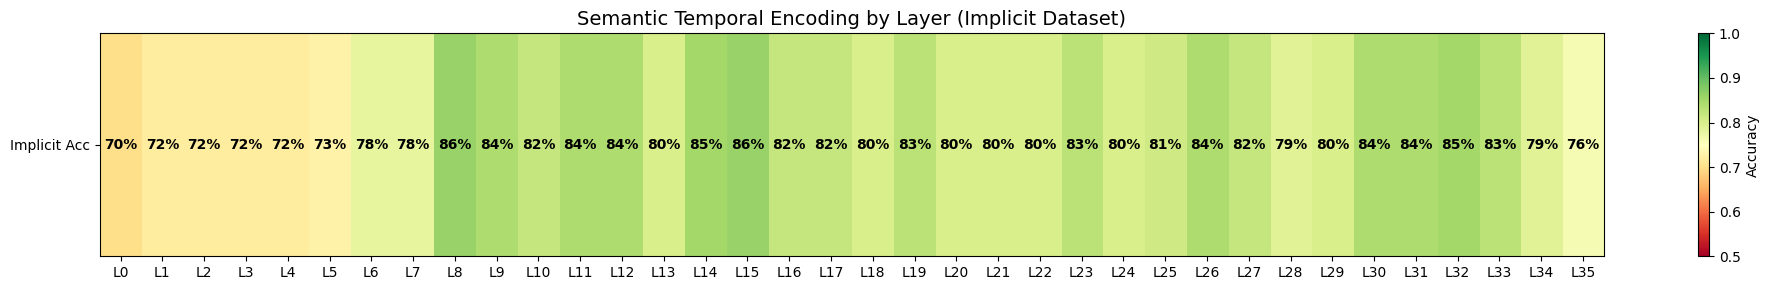

In [6]:
# Heatmap visualization
fig, ax = plt.subplots(figsize=(20, 3))

# Create heatmap data
heatmap_data = df[['implicit_acc']].T.values

im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)

# Labels
ax.set_xticks(range(len(x)))
ax.set_xticklabels([f'L{i}' for i in range(len(x))])
ax.set_yticks([0])
ax.set_yticklabels(['Implicit Acc'])

# Add text annotations
for i, acc in enumerate(df['implicit_acc']):
    color = 'white' if acc < 0.65 else 'black'
    ax.text(i, 0, f'{acc:.0%}', ha='center', va='center', color=color, fontweight='bold')

ax.set_title('Semantic Temporal Encoding by Layer (Implicit Dataset)', fontsize=14)
plt.colorbar(im, ax=ax, label='Accuracy')

plt.tight_layout()
plt.savefig(f'../results/figures/probe_validation_heatmap_{model_name}.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross-validation Analysis

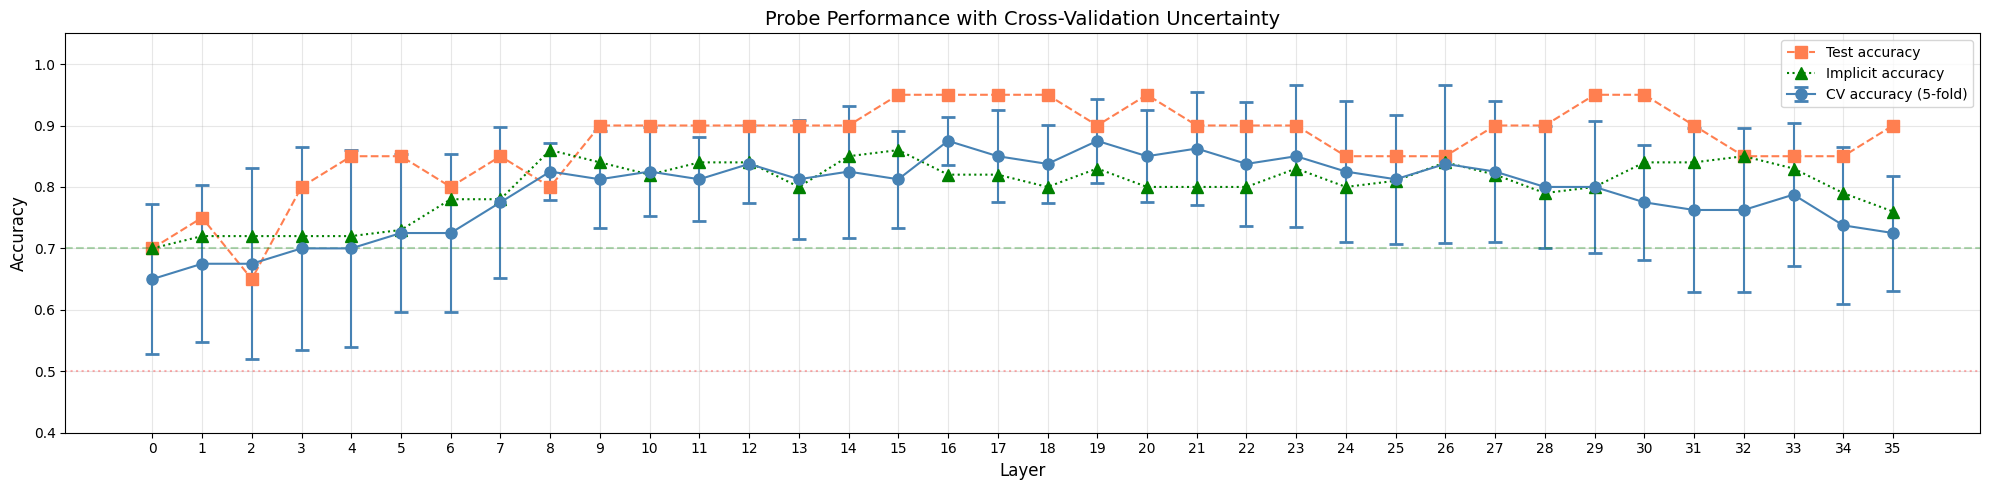


Note: Error bars show ±1 std from 5-fold cross-validation on explicit data


In [7]:
# Plot CV results with error bars
fig, ax = plt.subplots(figsize=(20, 5))

x = df['layer']
cv_mean = df['cv_mean']
cv_std = df['cv_std']

ax.errorbar(x, cv_mean, yerr=cv_std, fmt='o-', capsize=5, capthick=2, 
            color='steelblue', label='CV accuracy (5-fold)', markersize=8)
ax.plot(x, df['test_acc'], 's--', color='coral', label='Test accuracy', markersize=8)
ax.plot(x, df['implicit_acc'], '^:', color='green', label='Implicit accuracy', markersize=8)

ax.axhline(y=0.70, color='green', linestyle='--', alpha=0.3)
ax.axhline(y=0.50, color='red', linestyle=':', alpha=0.3)

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Probe Performance with Cross-Validation Uncertainty', fontsize=14)
ax.set_xticks(x)
ax.set_ylim(0.4, 1.05)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNote: Error bars show ±1 std from 5-fold cross-validation on explicit data")

# Analysing Phi

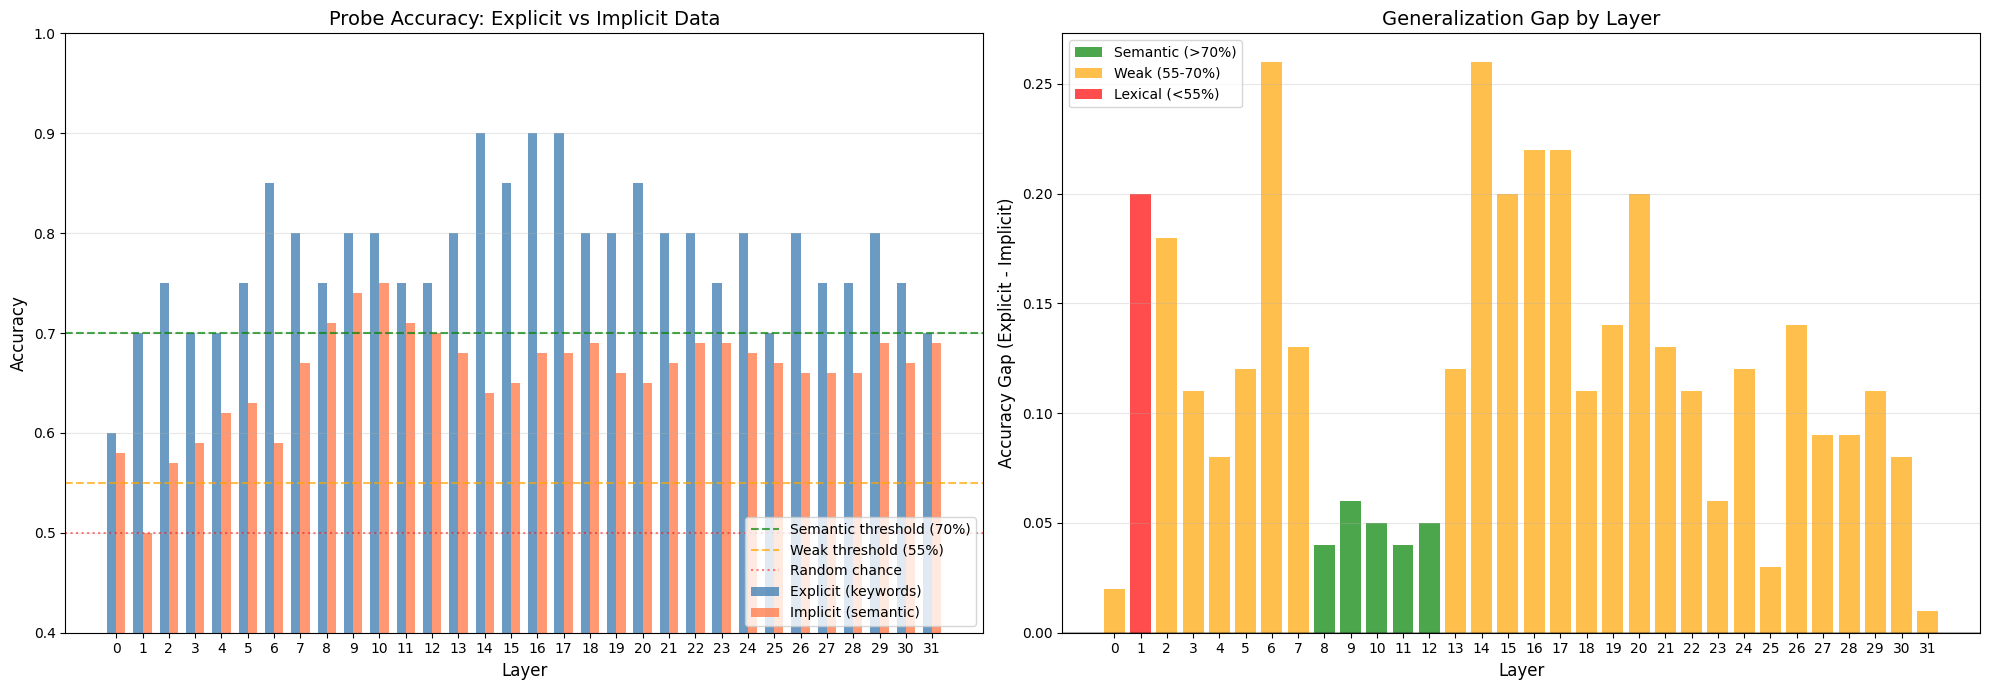


Figure saved to results/figures/probe_validation_Phi-3-mini-4k-instruct.png


In [8]:
# Plotting for Phi
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
model_name="Phi-3-mini-4k-instruct"
df = dfs[model_name]
# Plot 1: Accuracy comparison
ax1 = axes[0]
x = df['layer']
width = 0.35

bars1 = ax1.bar(x - width/2, df['test_acc'], width, label='Explicit (keywords)', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, df['implicit_acc'], width, label='Implicit (semantic)', color='coral', alpha=0.8)

ax1.axhline(y=0.70, color='green', linestyle='--', alpha=0.7, label='Semantic threshold (70%)')
ax1.axhline(y=0.55, color='orange', linestyle='--', alpha=0.7, label='Weak threshold (55%)')
ax1.axhline(y=0.50, color='red', linestyle=':', alpha=0.5, label='Random chance')

ax1.set_xlabel('Layer', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Probe Accuracy: Explicit vs Implicit Data', fontsize=14)
ax1.set_xticks(x)
ax1.set_ylim(0.4, 1.0)
ax1.legend(loc='lower right')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Gap between explicit and implicit
ax2 = axes[1]
colors = ['green' if s == 'SEMANTIC' else ('orange' if s == 'WEAK' else 'red') for s in df['status']]
ax2.bar(x, df['gap'], color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

ax2.set_xlabel('Layer', fontsize=12)
ax2.set_ylabel('Accuracy Gap (Explicit - Implicit)', fontsize=12)
ax2.set_title('Generalization Gap by Layer', fontsize=14)
ax2.set_xticks(x)
ax2.grid(axis='y', alpha=0.3)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Semantic (>70%)'),
    Patch(facecolor='orange', alpha=0.7, label='Weak (55-70%)'),
    Patch(facecolor='red', alpha=0.7, label='Lexical (<55%)')
]
ax2.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig(f'../results/figures/probe_validation_{model_name}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to results/figures/probe_validation_{model_name}.png")

In [9]:
print("=" * 70)
print("LAYER-BY-LAYER ANALYSIS")
print("=" * 70)
print()

for _, row in df.iterrows():
    layer = int(row['layer'])
    explicit = row['test_acc']
    implicit = row['implicit_acc']
    gap = row['gap']
    status = row['status']
    
    icon = '✓' if status == 'SEMANTIC' else ('○' if status == 'WEAK' else '✗')
    
    print(f"Layer {layer:2d}: {icon} {status:8s} | Explicit: {explicit:.1%} | Implicit: {implicit:.1%} | Gap: {gap:+.1%}")

LAYER-BY-LAYER ANALYSIS

Layer  0: ○ WEAK     | Explicit: 60.0% | Implicit: 58.0% | Gap: +2.0%
Layer  1: ✗ LEXICAL  | Explicit: 70.0% | Implicit: 50.0% | Gap: +20.0%
Layer  2: ○ WEAK     | Explicit: 75.0% | Implicit: 57.0% | Gap: +18.0%
Layer  3: ○ WEAK     | Explicit: 70.0% | Implicit: 59.0% | Gap: +11.0%
Layer  4: ○ WEAK     | Explicit: 70.0% | Implicit: 62.0% | Gap: +8.0%
Layer  5: ○ WEAK     | Explicit: 75.0% | Implicit: 63.0% | Gap: +12.0%
Layer  6: ○ WEAK     | Explicit: 85.0% | Implicit: 59.0% | Gap: +26.0%
Layer  7: ○ WEAK     | Explicit: 80.0% | Implicit: 67.0% | Gap: +13.0%
Layer  8: ✓ SEMANTIC | Explicit: 75.0% | Implicit: 71.0% | Gap: +4.0%
Layer  9: ✓ SEMANTIC | Explicit: 80.0% | Implicit: 74.0% | Gap: +6.0%
Layer 10: ✓ SEMANTIC | Explicit: 80.0% | Implicit: 75.0% | Gap: +5.0%
Layer 11: ✓ SEMANTIC | Explicit: 75.0% | Implicit: 71.0% | Gap: +4.0%
Layer 12: ✓ SEMANTIC | Explicit: 75.0% | Implicit: 70.0% | Gap: +5.0%
Layer 13: ○ WEAK     | Explicit: 80.0% | Implicit: 68.0% | 

In [10]:
summary = phi_results['summary']

print("=" * 50)
print("VALIDATION SUMMARY")
print("=" * 50)
print(f"Best semantic layer: {summary['best_semantic_layer']}")
print(f"Best implicit accuracy: {summary['best_implicit_accuracy']:.1%}")
print(f"Validation passed: {summary['validation_passed']}")
print()

# Statistics
semantic_layers = df[df['status'] == 'SEMANTIC']['layer'].tolist()
weak_layers = df[df['status'] == 'WEAK']['layer'].tolist()
lexical_layers = df[df['status'] == 'LEXICAL']['layer'].tolist()

print(f"Semantic layers (>70%): {semantic_layers}")
print(f"Weak layers (55-70%): {weak_layers}")
print(f"Lexical layers (<55%): {lexical_layers}")
print()

print(f"Mean explicit accuracy: {df['test_acc'].mean():.1%}")
print(f"Mean implicit accuracy: {df['implicit_acc'].mean():.1%}")
print(f"Mean generalization gap: {df['gap'].mean():.1%}")

VALIDATION SUMMARY
Best semantic layer: 10
Best implicit accuracy: 75.0%
Validation passed: True

Semantic layers (>70%): [8, 9, 10, 11, 12]
Weak layers (55-70%): [0, 2, 3, 4, 5, 6, 7, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Lexical layers (<55%): [1]

Mean explicit accuracy: 77.8%
Mean implicit accuracy: 66.0%
Mean generalization gap: 11.8%


### Observations

1. Layer 8-12 shows both high explicit as wella s implicit accuracy and also the lowest gap as compared to other layers.
2. Layer 10 is the best layer. Has higher implicit accuracy then explicit accuracy.

## SPD 

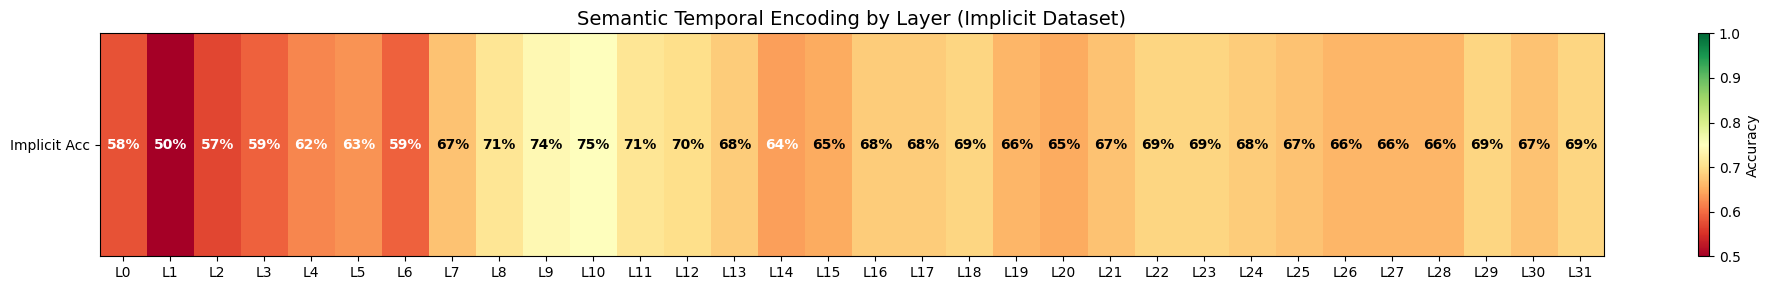

In [11]:
# Heatmap visualization
fig, ax = plt.subplots(figsize=(20, 3))

# Create heatmap data
heatmap_data = df[['implicit_acc']].T.values

im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)

# Labels
ax.set_xticks(range(len(x)))
ax.set_xticklabels([f'L{i}' for i in range(len(x))])
ax.set_yticks([0])
ax.set_yticklabels(['Implicit Acc'])

# Add text annotations
for i, acc in enumerate(df['implicit_acc']):
    color = 'white' if acc < 0.65 else 'black'
    ax.text(i, 0, f'{acc:.0%}', ha='center', va='center', color=color, fontweight='bold')

ax.set_title('Semantic Temporal Encoding by Layer (Implicit Dataset)', fontsize=14)
plt.colorbar(im, ax=ax, label='Accuracy')

plt.tight_layout()
plt.savefig(f'../results/figures/probe_validation_heatmap_{model_name}.png', dpi=150, bbox_inches='tight')
plt.show()

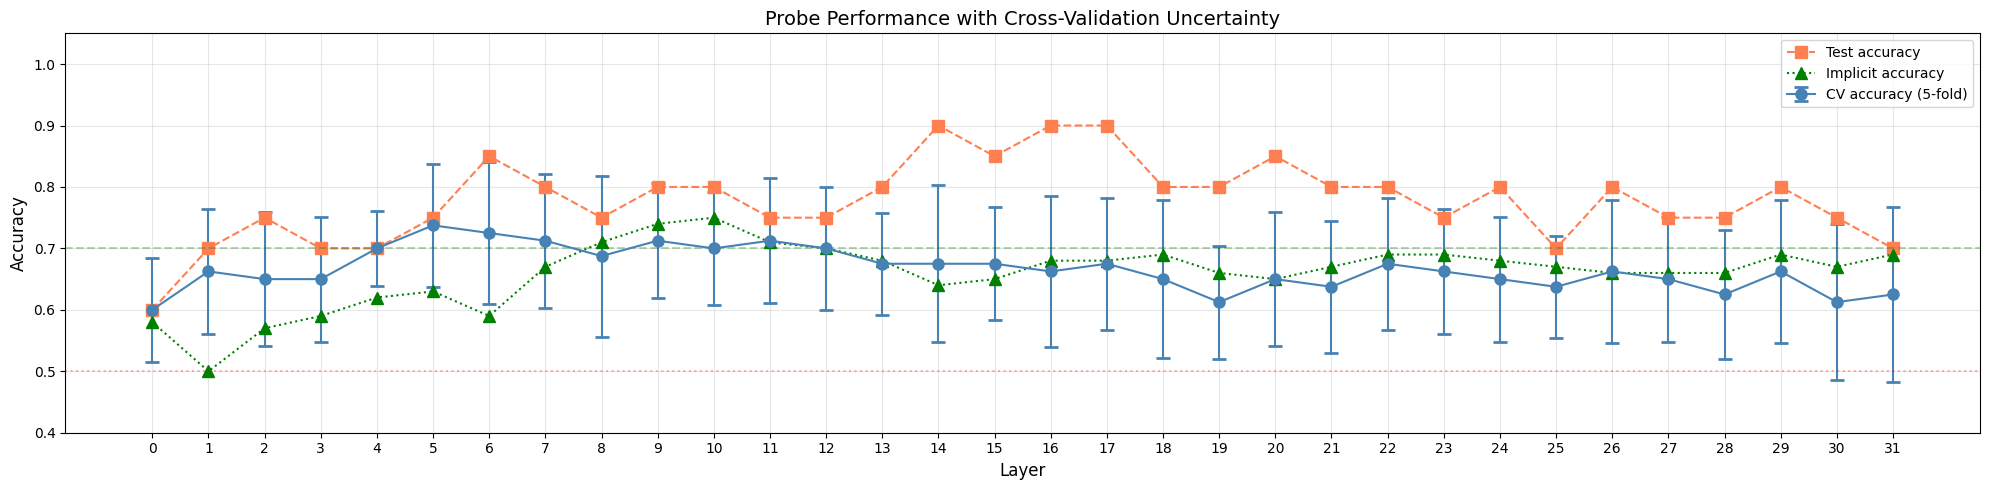


Note: Error bars show ±1 std from 5-fold cross-validation on explicit data


In [12]:
# Plot CV results with error bars
fig, ax = plt.subplots(figsize=(20, 5))

x = df['layer']
cv_mean = df['cv_mean']
cv_std = df['cv_std']

ax.errorbar(x, cv_mean, yerr=cv_std, fmt='o-', capsize=5, capthick=2, 
            color='steelblue', label='CV accuracy (5-fold)', markersize=8)
ax.plot(x, df['test_acc'], 's--', color='coral', label='Test accuracy', markersize=8)
ax.plot(x, df['implicit_acc'], '^:', color='green', label='Implicit accuracy', markersize=8)

ax.axhline(y=0.70, color='green', linestyle='--', alpha=0.3)
ax.axhline(y=0.50, color='red', linestyle=':', alpha=0.3)

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Probe Performance with Cross-Validation Uncertainty', fontsize=14)
ax.set_xticks(x)
ax.set_ylim(0.4, 1.05)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNote: Error bars show ±1 std from 5-fold cross-validation on explicit data")

# Analysing Llama

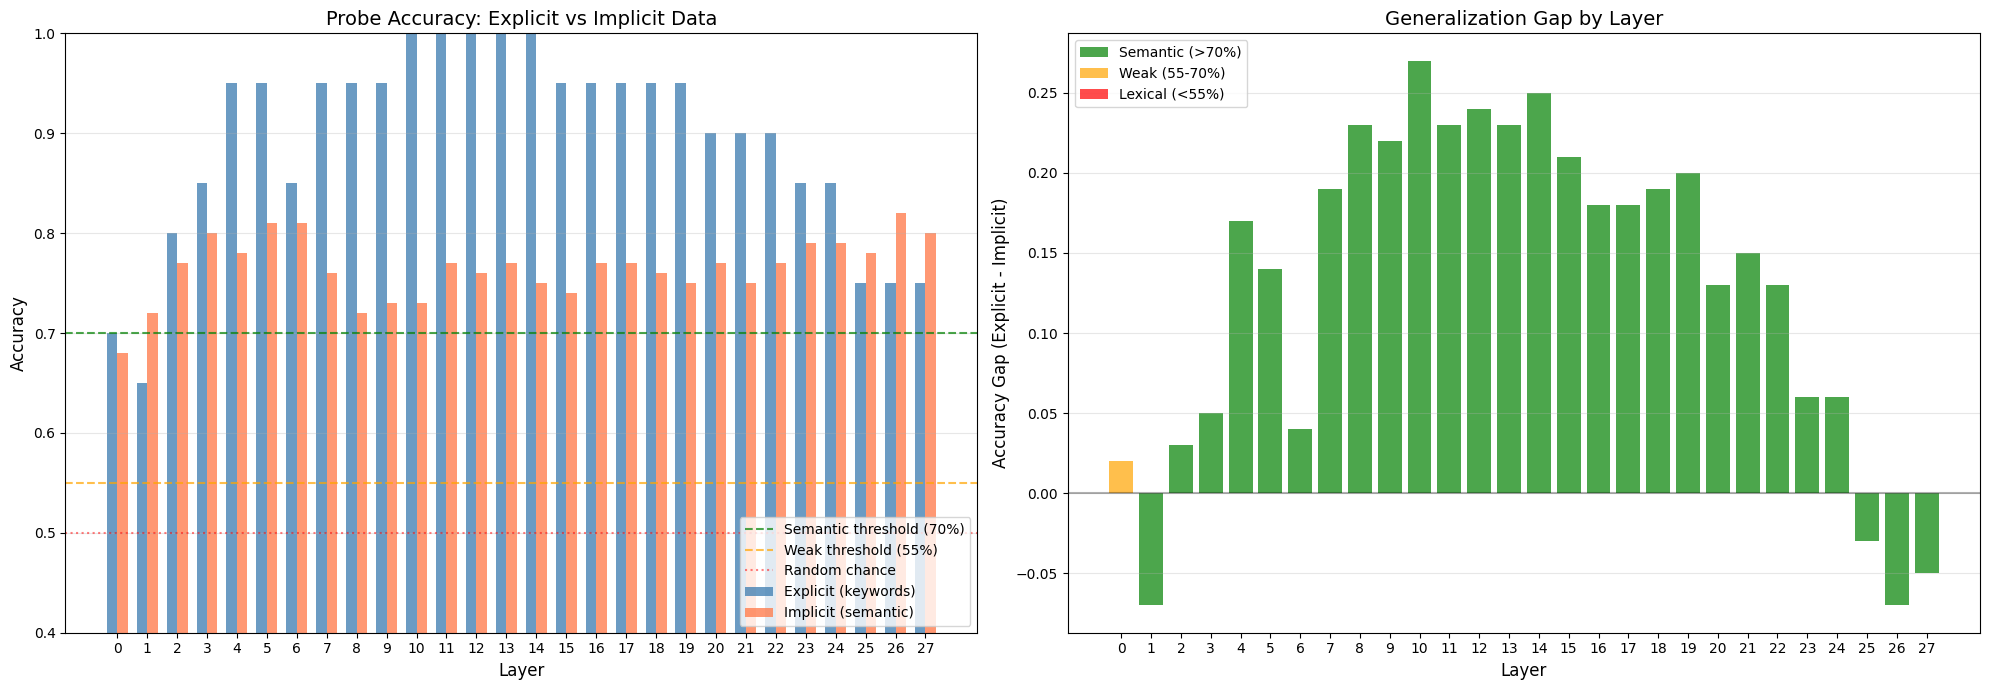


Figure saved to results/figures/probe_validation_Llama-3.2-3B.png


In [13]:
# Plotting for Phi
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
model_name="Llama-3.2-3B"
df = dfs[model_name]
# Plot 1: Accuracy comparison
ax1 = axes[0]
x = df['layer']
width = 0.35

bars1 = ax1.bar(x - width/2, df['test_acc'], width, label='Explicit (keywords)', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, df['implicit_acc'], width, label='Implicit (semantic)', color='coral', alpha=0.8)

ax1.axhline(y=0.70, color='green', linestyle='--', alpha=0.7, label='Semantic threshold (70%)')
ax1.axhline(y=0.55, color='orange', linestyle='--', alpha=0.7, label='Weak threshold (55%)')
ax1.axhline(y=0.50, color='red', linestyle=':', alpha=0.5, label='Random chance')

ax1.set_xlabel('Layer', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Probe Accuracy: Explicit vs Implicit Data', fontsize=14)
ax1.set_xticks(x)
ax1.set_ylim(0.4, 1.0)
ax1.legend(loc='lower right')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Gap between explicit and implicit
ax2 = axes[1]
colors = ['green' if s == 'SEMANTIC' else ('orange' if s == 'WEAK' else 'red') for s in df['status']]
ax2.bar(x, df['gap'], color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

ax2.set_xlabel('Layer', fontsize=12)
ax2.set_ylabel('Accuracy Gap (Explicit - Implicit)', fontsize=12)
ax2.set_title('Generalization Gap by Layer', fontsize=14)
ax2.set_xticks(x)
ax2.grid(axis='y', alpha=0.3)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Semantic (>70%)'),
    Patch(facecolor='orange', alpha=0.7, label='Weak (55-70%)'),
    Patch(facecolor='red', alpha=0.7, label='Lexical (<55%)')
]
ax2.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig(f'../results/figures/probe_validation_{model_name}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to results/figures/probe_validation_{model_name}.png")

In [14]:
print("=" * 70)
print("LAYER-BY-LAYER ANALYSIS")
print("=" * 70)
print()

for _, row in df.iterrows():
    layer = int(row['layer'])
    explicit = row['test_acc']
    implicit = row['implicit_acc']
    gap = row['gap']
    status = row['status']
    
    icon = '✓' if status == 'SEMANTIC' else ('○' if status == 'WEAK' else '✗')
    
    print(f"Layer {layer:2d}: {icon} {status:8s} | Explicit: {explicit:.1%} | Implicit: {implicit:.1%} | Gap: {gap:+.1%}")

LAYER-BY-LAYER ANALYSIS

Layer  0: ○ WEAK     | Explicit: 70.0% | Implicit: 68.0% | Gap: +2.0%
Layer  1: ✓ SEMANTIC | Explicit: 65.0% | Implicit: 72.0% | Gap: -7.0%
Layer  2: ✓ SEMANTIC | Explicit: 80.0% | Implicit: 77.0% | Gap: +3.0%
Layer  3: ✓ SEMANTIC | Explicit: 85.0% | Implicit: 80.0% | Gap: +5.0%
Layer  4: ✓ SEMANTIC | Explicit: 95.0% | Implicit: 78.0% | Gap: +17.0%
Layer  5: ✓ SEMANTIC | Explicit: 95.0% | Implicit: 81.0% | Gap: +14.0%
Layer  6: ✓ SEMANTIC | Explicit: 85.0% | Implicit: 81.0% | Gap: +4.0%
Layer  7: ✓ SEMANTIC | Explicit: 95.0% | Implicit: 76.0% | Gap: +19.0%
Layer  8: ✓ SEMANTIC | Explicit: 95.0% | Implicit: 72.0% | Gap: +23.0%
Layer  9: ✓ SEMANTIC | Explicit: 95.0% | Implicit: 73.0% | Gap: +22.0%
Layer 10: ✓ SEMANTIC | Explicit: 100.0% | Implicit: 73.0% | Gap: +27.0%
Layer 11: ✓ SEMANTIC | Explicit: 100.0% | Implicit: 77.0% | Gap: +23.0%
Layer 12: ✓ SEMANTIC | Explicit: 100.0% | Implicit: 76.0% | Gap: +24.0%
Layer 13: ✓ SEMANTIC | Explicit: 100.0% | Implicit: 77

In [15]:
summary = llama_results['summary']

print("=" * 50)
print("VALIDATION SUMMARY")
print("=" * 50)
print(f"Best semantic layer: {summary['best_semantic_layer']}")
print(f"Best implicit accuracy: {summary['best_implicit_accuracy']:.1%}")
print(f"Validation passed: {summary['validation_passed']}")
print()

# Statistics
semantic_layers = df[df['status'] == 'SEMANTIC']['layer'].tolist()
weak_layers = df[df['status'] == 'WEAK']['layer'].tolist()
lexical_layers = df[df['status'] == 'LEXICAL']['layer'].tolist()

print(f"Semantic layers (>70%): {semantic_layers}")
print(f"Weak layers (55-70%): {weak_layers}")
print(f"Lexical layers (<55%): {lexical_layers}")
print()

print(f"Mean explicit accuracy: {df['test_acc'].mean():.1%}")
print(f"Mean implicit accuracy: {df['implicit_acc'].mean():.1%}")
print(f"Mean generalization gap: {df['gap'].mean():.1%}")

VALIDATION SUMMARY
Best semantic layer: 26
Best implicit accuracy: 82.0%
Validation passed: True

Semantic layers (>70%): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
Weak layers (55-70%): [0]
Lexical layers (<55%): []

Mean explicit accuracy: 89.3%
Mean implicit accuracy: 76.5%
Mean generalization gap: 12.8%


### Observations 

1. Layer 10-14 depict highest Explicit accuarcy as well as some of teh highest generalization gap.
2. Other than layer 0 all layers encode semantic temporal features.


## SPD

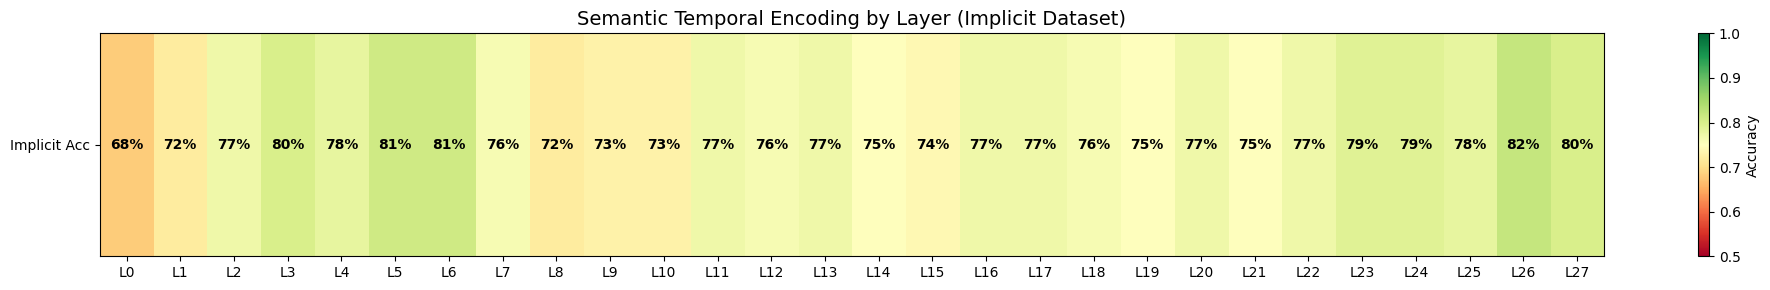

In [16]:
# Heatmap visualization
fig, ax = plt.subplots(figsize=(20, 3))

# Create heatmap data
heatmap_data = df[['implicit_acc']].T.values

im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)

# Labels
ax.set_xticks(range(len(x)))
ax.set_xticklabels([f'L{i}' for i in range(len(x))])
ax.set_yticks([0])
ax.set_yticklabels(['Implicit Acc'])

# Add text annotations
for i, acc in enumerate(df['implicit_acc']):
    color = 'white' if acc < 0.65 else 'black'
    ax.text(i, 0, f'{acc:.0%}', ha='center', va='center', color=color, fontweight='bold')

ax.set_title('Semantic Temporal Encoding by Layer (Implicit Dataset)', fontsize=14)
plt.colorbar(im, ax=ax, label='Accuracy')

plt.tight_layout()
plt.savefig(f'../results/figures/probe_validation_heatmap_{model_name}.png', dpi=150, bbox_inches='tight')
plt.show()

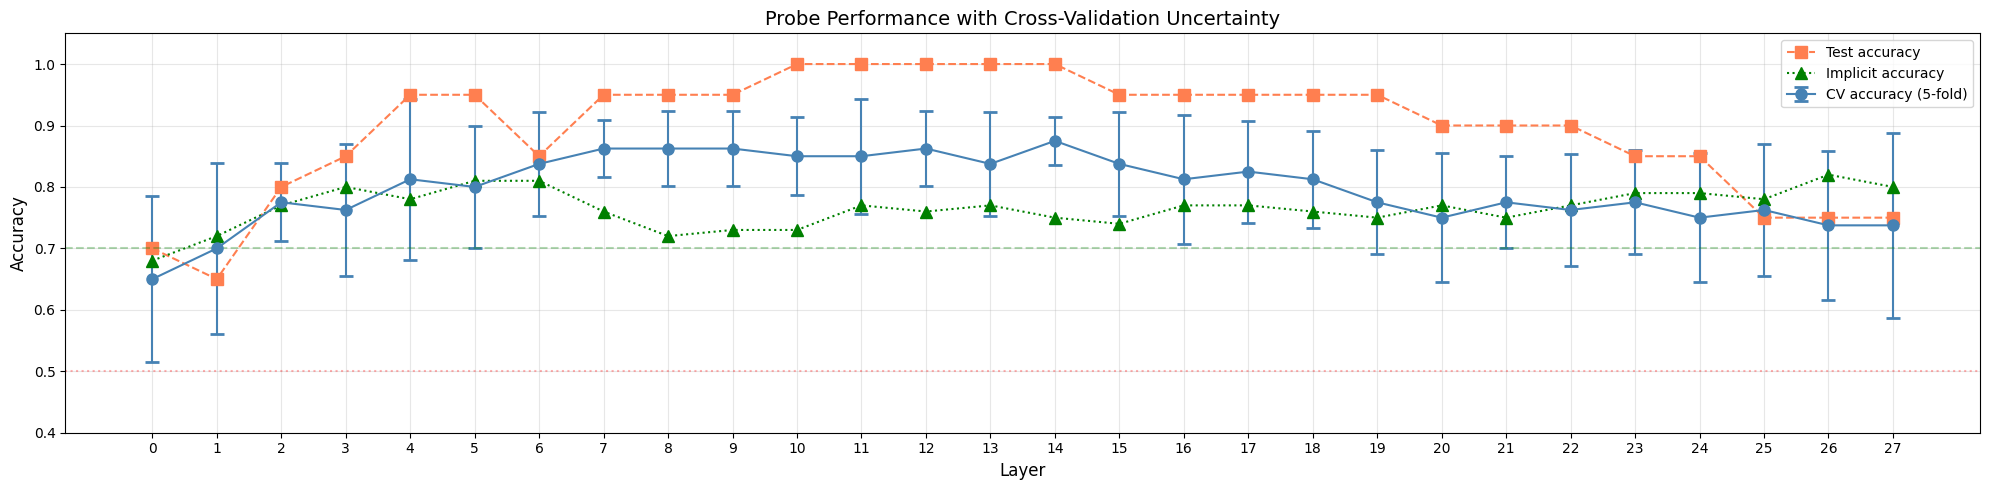


Note: Error bars show ±1 std from 5-fold cross-validation on explicit data


In [17]:
# Plot CV results with error bars
fig, ax = plt.subplots(figsize=(20, 5))

x = df['layer']
cv_mean = df['cv_mean']
cv_std = df['cv_std']

ax.errorbar(x, cv_mean, yerr=cv_std, fmt='o-', capsize=5, capthick=2, 
            color='steelblue', label='CV accuracy (5-fold)', markersize=8)
ax.plot(x, df['test_acc'], 's--', color='coral', label='Test accuracy', markersize=8)
ax.plot(x, df['implicit_acc'], '^:', color='green', label='Implicit accuracy', markersize=8)

ax.axhline(y=0.70, color='green', linestyle='--', alpha=0.3)
ax.axhline(y=0.50, color='red', linestyle=':', alpha=0.3)

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Probe Performance with Cross-Validation Uncertainty', fontsize=14)
ax.set_xticks(x)
ax.set_ylim(0.4, 1.05)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNote: Error bars show ±1 std from 5-fold cross-validation on explicit data")